In [494]:
#Librerias
import pandas as pd
import numpy as np
import math
from viewx.datasets import load_dataset
from viewx import HTML
import matplotlib.pyplot as plt
import plotly.express as px
import json
import plotly.io as pio
import webbrowser
import os

In [495]:
df=pd.read_excel("WHR25_Data_Figure_2.1.xlsx")
# Agrupar por country name y años
df.groupby(by=["Year","Country name"]).agg({"Ladder score": "mean"}).reset_index()
df

,Year,Rank,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2024,1,Finland,7.736,7.810,7.662,1.749,1.783,0.824,0.986,0.110,0.502,1.782
1,2023,143,Afghanistan,1.721,1.775,1.667,0.628,0.000,0.242,0.000,0.091,0.088,0.672
2,2022,137,Afghanistan,1.859,1.923,1.795,0.645,0.000,0.087,0.000,0.093,0.059,0.976
3,2021,146,Afghanistan,2.404,2.469,2.339,0.758,0.000,0.289,0.000,0.089,0.005,1.263
4,2020,150,Afghanistan,2.523,2.596,2.449,0.370,0.000,0.126,0.000,0.122,0.010,1.895
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016,138,Zimbabwe,3.875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1965,2015,131,Zimbabwe,4.193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1966,2014,115,Zimbabwe,4.610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967,2012,103,Zimbabwe,4.827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [496]:
df["Country name"].value_counts()

Country name
Finland        13
Afghanistan    13
Denmark        13
Albania        13
Iceland        13
               ..
Maldives        2
Puerto Rico     2
Cuba            1
Guyana          1
Macedonia       1
Name: count, Length: 169, dtype: int64

In [497]:
dfmf24= df[df["Year"]== 2024].sort_values(by="Ladder score", ascending=False)[:20]
dfmf23= df[df["Year"]== 2023].sort_values(by="Ladder score", ascending=False)[:20]
dfmf22= df[df["Year"]== 2022].sort_values(by="Ladder score", ascending=False)[:20]
dfmf21= df[df["Year"]== 2021].sort_values(by="Ladder score", ascending=False)[:20]
dfmf20= df[df["Year"]== 2020].sort_values(by="Ladder score", ascending=False)[:20]
dfmf19= df[df["Year"]== 2019].sort_values(by="Ladder score", ascending=False)[:20]
dfmf18= df[df["Year"]== 2018].sort_values(by="Ladder score", ascending=False)[:20]
dfmf17= df[df["Year"]== 2017].sort_values(by="Ladder score", ascending=False)[:20]
dfmf16= df[df["Year"]== 2016].sort_values(by="Ladder score", ascending=False)[:20]
dfmf15= df[df["Year"]== 2015].sort_values(by="Ladder score", ascending=False)[:20]
dfmf14= df[df["Year"]== 2014].sort_values(by="Ladder score", ascending=False)[:20]
dfmf13= df[df["Year"]== 2013].sort_values(by="Ladder score", ascending=False)[:20]
dfmf12= df[df["Year"]== 2012].sort_values(by="Ladder score", ascending=False)[:20]
dfmf11= df[df["Year"]== 2011].sort_values(by="Ladder score", ascending=False)[:20]

dfmf11

,Year,Rank,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
467,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
575,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1334,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1248,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1696,2011,6,Switzerland,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1683,2011,7,Sweden,7.379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1261,2011,8,New Zealand,7.372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
83,2011,9,Australia,7.345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
812,2011,10,Ireland,7.284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


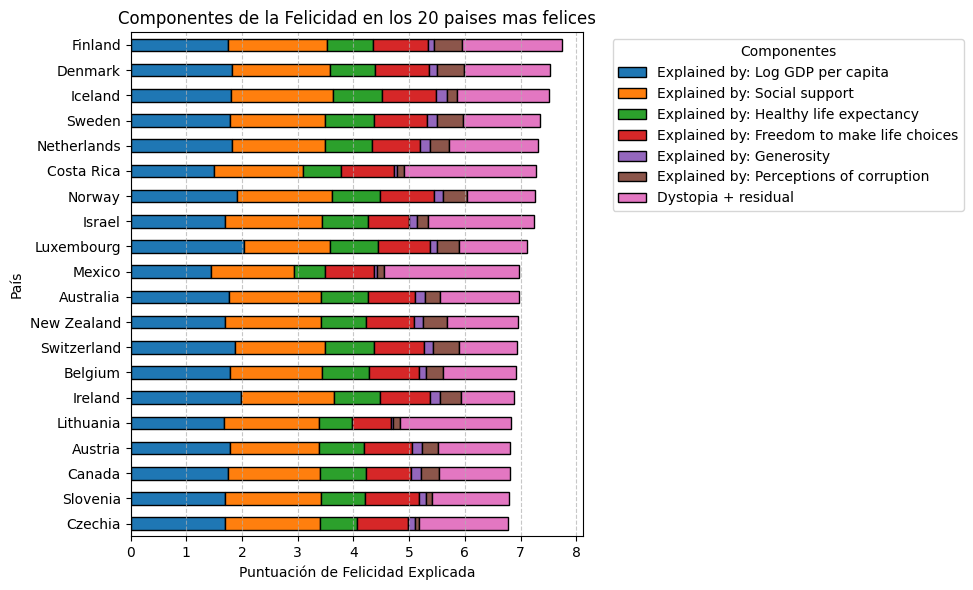

In [498]:
####### Grafica de los 20 paises mas felices 2024


# Filtrar los datos para los países y el año especificados
df_filtered = dfmf24.head(20)

# Definir las columnas de las componentes explicativas
explained_cols = [
    'Explained by: Log GDP per capita',
    'Explained by: Social support',
    'Explained by: Healthy life expectancy',
    'Explained by: Freedom to make life choices',
    'Explained by: Generosity',
    'Explained by: Perceptions of corruption',
    'Dystopia + residual'
]

# Seleccionar las columnas relevantes y establecer el nombre del país como índice
df_plot = df_filtered.set_index('Country name')[explained_cols]

df_plot = df_plot.iloc[::-1]

# Crear la gráfica de barras apiladas horizontal
ax = df_plot.plot(kind='barh', stacked=True, figsize=(10, 6),edgecolor='black', linewidth=1)
plt.title(f'Componentes de la Felicidad en los 20 paises mas felices')
plt.xlabel('Puntuación de Felicidad Explicada')
plt.ylabel('País')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Componentes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('felices2024.png')
plt.show()

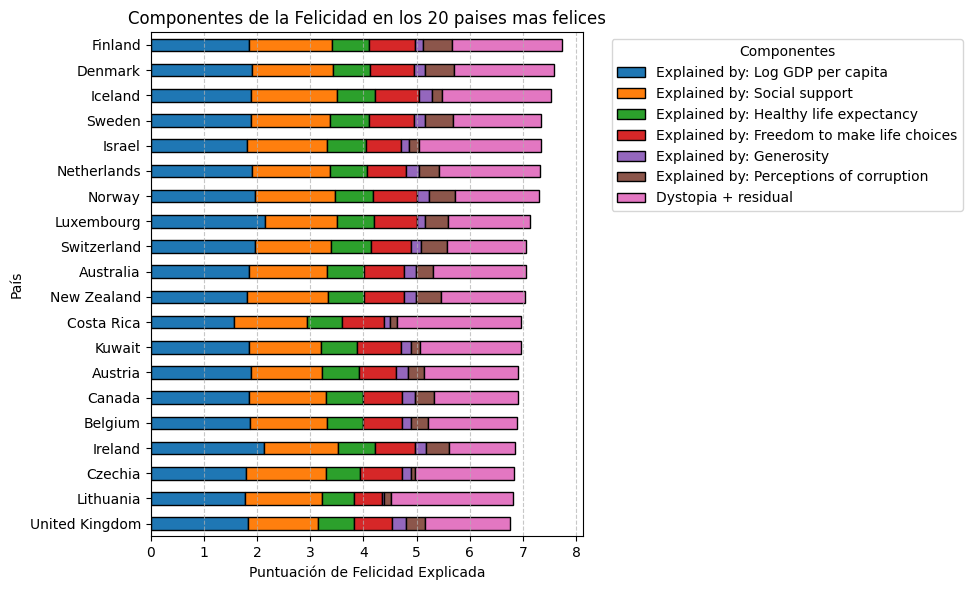

,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
Country name,,,,,,,
United Kingdom,1.822,1.326,0.672,0.713,0.267,0.351,1.598
Lithuania,1.766,1.454,0.598,0.533,0.044,0.116,2.307
Czechia,1.783,1.511,0.638,0.787,0.177,0.068,1.858
Ireland,2.129,1.390,0.700,0.758,0.205,0.418,1.239
Belgium,1.868,1.440,0.690,0.729,0.170,0.311,1.686
Canada,1.840,1.459,0.701,0.730,0.230,0.368,1.572
Austria,1.885,1.336,0.696,0.703,0.214,0.305,1.766
Kuwait,1.845,1.364,0.661,0.827,0.200,0.172,1.884
Costa Rica,1.561,1.373,0.661,0.797,0.109,0.123,2.333


In [499]:
####### Grafica de los 20 paises mas felices 2023


# Filtrar los datos para los países y el año especificados
df_filtered = dfmf23.head(20)

# Definir las columnas de las componentes explicativas
explained_cols = [
    'Explained by: Log GDP per capita',
    'Explained by: Social support',
    'Explained by: Healthy life expectancy',
    'Explained by: Freedom to make life choices',
    'Explained by: Generosity',
    'Explained by: Perceptions of corruption',
    'Dystopia + residual'
]

# Seleccionar las columnas relevantes y establecer el nombre del país como índice
df_plot = df_filtered.set_index('Country name')[explained_cols]

df_plot = df_plot.iloc[::-1]

# Crear la gráfica de barras apiladas horizontal
df_plot.plot(kind='barh', stacked=True, figsize=(10, 6),edgecolor='black', linewidth=1)
plt.title(f'Componentes de la Felicidad en los 20 paises mas felices')
plt.xlabel('Puntuación de Felicidad Explicada')
plt.ylabel('País')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Componentes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('felices2023.png')
plt.show()

df_plot

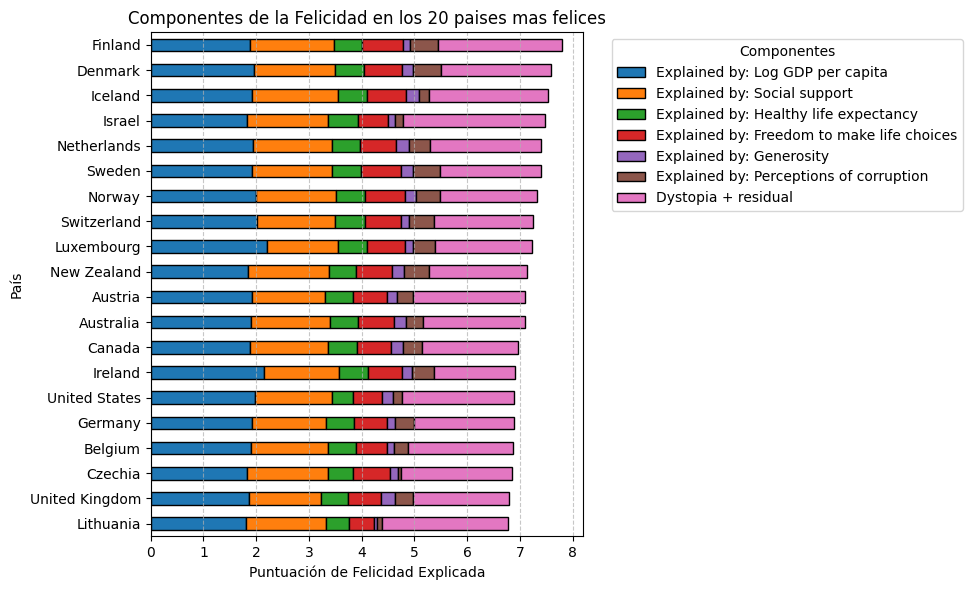

In [500]:
####### Grafica de los 20 paises mas felices 2022


# Filtrar los datos para los países y el año especificados
df_filtered = dfmf22.head(20)

# Definir las columnas de las componentes explicativas
explained_cols = [
    'Explained by: Log GDP per capita',
    'Explained by: Social support',
    'Explained by: Healthy life expectancy',
    'Explained by: Freedom to make life choices',
    'Explained by: Generosity',
    'Explained by: Perceptions of corruption',
    'Dystopia + residual'
]

# Seleccionar las columnas relevantes y establecer el nombre del país como índice
df_plot = df_filtered.set_index('Country name')[explained_cols]

df_plot = df_plot.iloc[::-1]

# Crear la gráfica de barras apiladas horizontal
ax = df_plot.plot(kind='barh', stacked=True, figsize=(10, 6),edgecolor='black', linewidth=1)
plt.title(f'Componentes de la Felicidad en los 20 paises mas felices')
plt.xlabel('Puntuación de Felicidad Explicada')
plt.ylabel('País')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Componentes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('felices2022.png')
plt.show()

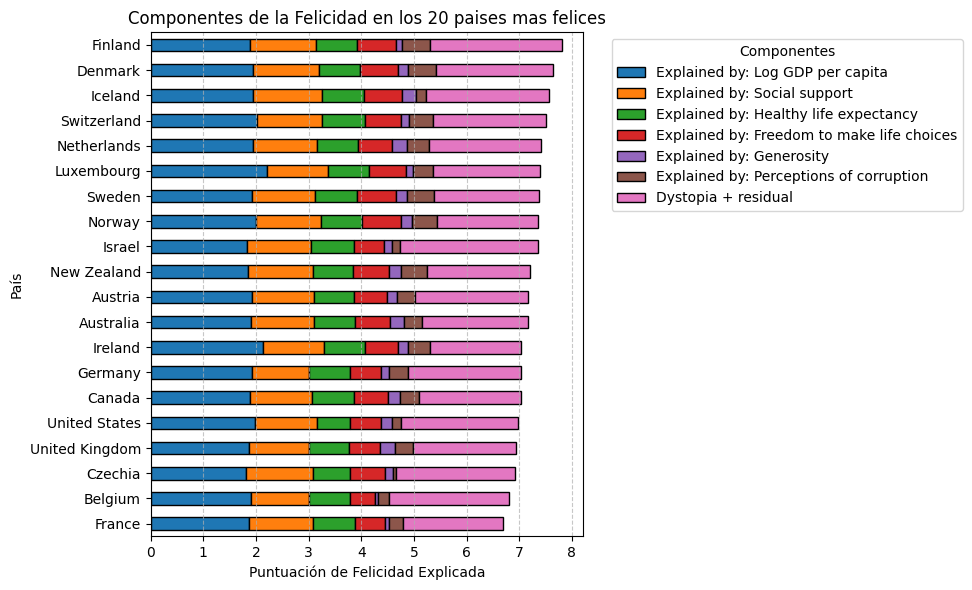

In [501]:
####### Grafica de los 20 paises mas felices 2021


# Filtrar los datos para los países y el año especificados
df_filtered = dfmf21.head(20)

# Definir las columnas de las componentes explicativas
explained_cols = [
    'Explained by: Log GDP per capita',
    'Explained by: Social support',
    'Explained by: Healthy life expectancy',
    'Explained by: Freedom to make life choices',
    'Explained by: Generosity',
    'Explained by: Perceptions of corruption',
    'Dystopia + residual'
]

# Seleccionar las columnas relevantes y establecer el nombre del país como índice
df_plot = df_filtered.set_index('Country name')[explained_cols]

df_plot = df_plot.iloc[::-1]

# Crear la gráfica de barras apiladas horizontal
ax = df_plot.plot(kind='barh', stacked=True, figsize=(10, 6),edgecolor='black', linewidth=1)
plt.title(f'Componentes de la Felicidad en los 20 paises mas felices')
plt.xlabel('Puntuación de Felicidad Explicada')
plt.ylabel('País')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Componentes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('felices2021.png')
plt.show()

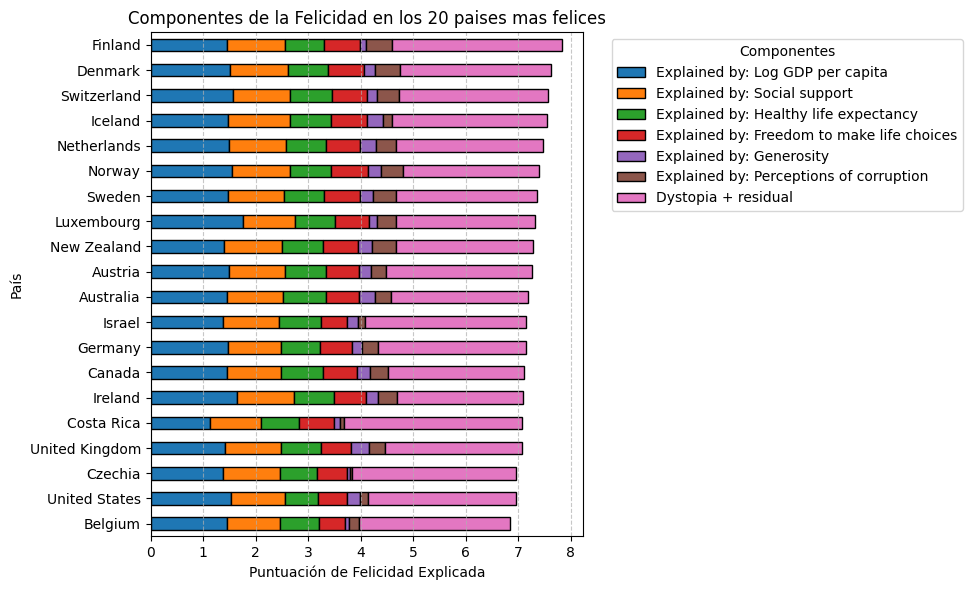

In [502]:
####### Grafica de los 20 paises mas felices 2020


# Filtrar los datos para los países y el año especificados
df_filtered = dfmf20.head(20)

# Definir las columnas de las componentes explicativas
explained_cols = [
    'Explained by: Log GDP per capita',
    'Explained by: Social support',
    'Explained by: Healthy life expectancy',
    'Explained by: Freedom to make life choices',
    'Explained by: Generosity',
    'Explained by: Perceptions of corruption',
    'Dystopia + residual'
]

# Seleccionar las columnas relevantes y establecer el nombre del país como índice
df_plot = df_filtered.set_index('Country name')[explained_cols]

df_plot = df_plot.iloc[::-1]

# Crear la gráfica de barras apiladas horizontal
ax = df_plot.plot(kind='barh', stacked=True, figsize=(10, 6),edgecolor='black', linewidth=1)
plt.title(f'Componentes de la Felicidad en los 20 paises mas felices')
plt.xlabel('Puntuación de Felicidad Explicada')
plt.ylabel('País')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Componentes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.savefig('felices2020.png')
plt.show()

In [503]:
### Base de datos para HTML
df = load_dataset("WHR25_Data_Figure_2.1.xlsx")
df_colombia = df[df["Country name"] == "Colombia"].sort_values(by="Year")

In [504]:
df

,Year,Rank,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2024,1,Finland,7.736,7.810,7.662,1.749,1.783,0.824,0.986,0.110,0.502,1.782
1,2023,143,Afghanistan,1.721,1.775,1.667,0.628,0.000,0.242,0.000,0.091,0.088,0.672
2,2022,137,Afghanistan,1.859,1.923,1.795,0.645,0.000,0.087,0.000,0.093,0.059,0.976
3,2021,146,Afghanistan,2.404,2.469,2.339,0.758,0.000,0.289,0.000,0.089,0.005,1.263
4,2020,150,Afghanistan,2.523,2.596,2.449,0.370,0.000,0.126,0.000,0.122,0.010,1.895
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016,138,Zimbabwe,3.875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1965,2015,131,Zimbabwe,4.193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1966,2014,115,Zimbabwe,4.610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1967,2012,103,Zimbabwe,4.827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [505]:
# df = df.sort_values(by=["Year", "Rank", "Ladder score"], ascending=[True, True, False])[:]
# result = pd.concat([
#     df.iloc[0:20],
#     df.iloc[156:176],
#     df.iloc[312:332],
#     df.iloc[470:490],
#     df.iloc[627:647],
#     df.iloc[782:802],
#     df.iloc[938:958],
#     df.iloc[1094:1114],
#     df.iloc[1247:1266],
#     df.iloc[1396:1416],
#     df.iloc[1542:1562],
#     df.iloc[1679:1699],
#     df.iloc[1822:1842],
# ])
# result = result.sort_values(
#     ["Year", "Rank"],
#     ascending=[True, False]
# )
# result

In [506]:
dfmf_super = pd.concat([
    dfmf24,
    dfmf23,
    dfmf22,
    dfmf21,
    dfmf20,
    dfmf19,
    dfmf18,
    dfmf17,
    dfmf16,
    dfmf15,
    dfmf14,
    dfmf13,
    dfmf12,
    dfmf11,
])

dfmf_super.to_csv('dfmf_super.csv', index=False)

# Comienzo del HTML

In [511]:
top_felices = HTML(
    data=dfmf_super,
    title="Top happiest countries",
    template_color=6,
    num_divs=4,
    num_cols=9,
    num_rows=3
)

¡Bienvenido a ViewX!
Encendiendo Motores...


In [512]:
top_felices.add_text(
    f"""
    <style>
        title {{
            transition: 0.3s ease;
        }}
        .title:hover {{
            transform: scale(1.1);
            transition: 0.2s;
        }}
        ::-webkit-scrollbar {{
            display: none;
        }}

    </style>
    <div style="align-items: center;">
        <h1 class = "title" style = "
                    text-align: center; 
                    font-size: 90px;
                    ">
                    Top 20 happiest countries
        </h1>
    </div>
    """,
    slot_grid=("div1", 1, 1, 1, 7)
)

Cargando Texto...


In [513]:
import pandas as pd
import plotly.express as px

# Asumiendo que df es tu DataFrame completo
# Crear los dataframes por año
# dfmf11 = df[df['Year'] == 2011].head(20)
# dfmf12 = df[df['Year'] == 2012].head(20)
# dfmf14 = df[df['Year'] == 2014].head(20)
# dfmf15 = df[df['Year'] == 2015].head(20)
# dfmf16 = df[df['Year'] == 2016].head(20)
# dfmf17 = df[df['Year'] == 2017].head(20)
# dfmf18 = df[df['Year'] == 2018].head(20)
# dfmf19 = df[df['Year'] == 2019].head(20)
# dfmf20 = df[df['Year'] == 2020].head(20)
# dfmf21 = df[df['Year'] == 2021].head(20)
# dfmf22 = df[df['Year'] == 2022].head(20)
# dfmf23 = df[df['Year'] == 2023].head(20)
# dfmf24 = df[df['Year'] == 2024].head(20)

# Función para crear figura con estilo consistente
def create_happiness_fig(df, year):
    fig = px.bar(
        df[::-1],  # Invertir para mejor visualización
        x="Ladder score",
        y="Country name",
        title=f"Top Happiness in the World - {year}",
        color="Country name",
        color_discrete_sequence=px.colors.sequential.Viridis,
        orientation='h'
    )
    
    fig.update_layout(
        margin=dict(l=100, r=20, t=50, b=40),
        paper_bgcolor="#f5f5f5",
        plot_bgcolor="#f5f5f5",
        font=dict(color="#1B4332", size=11),
        xaxis=dict(
            title="Ladder Score",
            gridcolor="rgba(0,0,0,0.1)",
            linecolor="#1B4332"
        ),
        yaxis=dict(
            title="",
            gridcolor="rgba(0,0,0,0.1)",
            linecolor="#1B4332",
            autorange="reversed"
        ),
        showlegend=False,
        autosize=True
    )
    
    return fig

# Crear las figuras
fig1 = create_happiness_fig(dfmf11, 2011)
fig2 = create_happiness_fig(dfmf12, 2012)
fig3 = create_happiness_fig(dfmf14, 2014)
fig4 = create_happiness_fig(dfmf15, 2015)
fig5 = create_happiness_fig(dfmf16, 2016)
fig6 = create_happiness_fig(dfmf17, 2017)
fig7 = create_happiness_fig(dfmf18, 2018)
fig8 = create_happiness_fig(dfmf19, 2019)
fig9 = create_happiness_fig(dfmf20, 2020)
fig10 = create_happiness_fig(dfmf21, 2021)
fig11 = create_happiness_fig(dfmf22, 2022)
fig12 = create_happiness_fig(dfmf23, 2023)
fig13 = create_happiness_fig(dfmf24, 2024)

# Convertir a JSON
plot_tabs1_json = fig1.to_json()
plot_tabs2_json = fig2.to_json()
plot_tabs3_json = fig3.to_json()
plot_tabs4_json = fig4.to_json()
plot_tabs5_json = fig5.to_json()
plot_tabs6_json = fig6.to_json()
plot_tabs7_json = fig7.to_json()
plot_tabs8_json = fig8.to_json()
plot_tabs9_json = fig9.to_json()
plot_tabs10_json = fig10.to_json()
plot_tabs11_json = fig11.to_json()
plot_tabs12_json = fig12.to_json()
plot_tabs13_json = fig13.to_json()

top_felices.add_text(
    f"""
    <div style="
        background:#EEF7F0;
        color:#1B4332;
        border:1px solid #1B433222;
        padding:14px;
        border-radius:12px;
        width:100%; height:100%;
        box-sizing:border-box;
        line-height:1.5;
        overflow:hidden;
        font-family:Arial;
        display:flex;
        flex-direction:column;
    ">
        
    <div class="tabs-group" id="groupB" style="height:100%; display:flex; flex-direction:column;">
        <div class="tab-buttons">
            <button onclick="openTabGroup('groupB', 'tab1_')">2011</button>
            <button onclick="openTabGroup('groupB', 'tab2_')">2012</button>
            <button onclick="openTabGroup('groupB', 'tab3_')">2014</button>
            <button onclick="openTabGroup('groupB', 'tab4_')">2015</button>
            <button onclick="openTabGroup('groupB', 'tab5_')">2016</button>
            <button onclick="openTabGroup('groupB', 'tab6_')">2017</button>
            <button onclick="openTabGroup('groupB', 'tab7_')">2018</button>
            <button onclick="openTabGroup('groupB', 'tab8_')">2019</button>
            <button onclick="openTabGroup('groupB', 'tab9_')">2020</button>
            <button onclick="openTabGroup('groupB', 'tab10_')">2021</button>
            <button onclick="openTabGroup('groupB', 'tab11_')">2022</button>
            <button onclick="openTabGroup('groupB', 'tab12_')">2023</button>
            <button onclick="openTabGroup('groupB', 'tab13_')">2024</button>
        </div>

        <div id="tab1_" class="tab-content-secondary active" style="flex:1; min-height:0;">
            <div id="plot1_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab2_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot2_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab3_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot3_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab4_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot4_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab5_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot5_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab6_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot6_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab7_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot7_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab8_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot8_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab9_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot9_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab10_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot10_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab11_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot11_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab12_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot12_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
        <div id="tab13_" class="tab-content-secondary" style="flex:1; min-height:0;">
            <div id="plot13_" class="plotly-container" style="width:100%; height:100%;"></div>
        </div>
    </div>

    <style>
    .tabs-group {{
        background: #2D6A4F;
        padding: 12px;
        border-radius: 8px;
        height: 100%;
        display: flex;
        flex-direction: column;
    }}

    .tab-buttons {{
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(80px, 1fr));
        gap: 6px;
        margin-bottom: 12px;
        flex-shrink: 0;
    }}

    .tab-buttons button {{
        padding: 8px 10px;
        border: none;
        background: #1B4332;
        color: white;
        cursor: pointer;
        border-radius: 6px;
        transition: 0.3s;
        font-size: 13px;
        font-weight: 500;
        white-space: nowrap;
        overflow: hidden;
        text-overflow: ellipsis;
    }}

    .tab-buttons button:hover {{
        background: #40916C;
    }}

    .tab-buttons button.active {{
        background: #74C69D;
        color: #1B4332;
        font-weight: bold;
    }}

    .tab-content-secondary {{
        display: none;
        background: #f5f5f5;
        padding: 10px;
        border-radius: 8px;
        flex: 1;
        min-height: 0;
        width: 100%;
        box-sizing: border-box;
    }}

    .tab-content-secondary.active {{
        display: block;
    }}

    .plotly-container {{
        width: 100%;
        height: 100%;
        min-height: 400px;
    }}

    .plotly-container .js-plotly-plot,
    .plotly-container .plotly,
    .plotly-container .plot-container,
    .plotly-container .svg-container {{
        width: 100% !important;
        height: 100% !important;
    }}
    </style>

    <script src="https://cdn.plot.ly/plotly-2.30.0.min.js"></script>    
    <script>
        // Configuración de las figuras
        var fig1 = {plot_tabs1_json};
        var fig2 = {plot_tabs2_json};
        var fig3 = {plot_tabs3_json};
        var fig4 = {plot_tabs4_json};
        var fig5 = {plot_tabs5_json};
        var fig6 = {plot_tabs6_json};
        var fig7 = {plot_tabs7_json};
        var fig8 = {plot_tabs8_json};
        var fig9 = {plot_tabs9_json};
        var fig10 = {plot_tabs10_json};
        var fig11 = {plot_tabs11_json};
        var fig12 = {plot_tabs12_json};
        var fig13 = {plot_tabs13_json};

        // Asegurar que las figuras tengan autosize=True
        [fig1, fig2, fig3, fig4, fig5, fig6, fig7, fig8, fig9, fig10, fig11, fig12, fig13].forEach(function(fig) {{
            if (!fig.layout) fig.layout = {{}};
            fig.layout.autosize = true;
            fig.layout.width = null;
            fig.layout.height = null;
            fig.layout.margin = {{l: 100, r: 30, t: 50, b: 40}};
        }});

        // Mapa de figuras por tab
        var figs = {{
            'tab1_': {{data: fig1.data, layout: fig1.layout, div: "plot1_"}},
            'tab2_': {{data: fig2.data, layout: fig2.layout, div: "plot2_"}},
            'tab3_': {{data: fig3.data, layout: fig3.layout, div: "plot3_"}},
            'tab4_': {{data: fig4.data, layout: fig4.layout, div: "plot4_"}},
            'tab5_': {{data: fig5.data, layout: fig5.layout, div: "plot5_"}},
            'tab6_': {{data: fig6.data, layout: fig6.layout, div: "plot6_"}},
            'tab7_': {{data: fig7.data, layout: fig7.layout, div: "plot7_"}},
            'tab8_': {{data: fig8.data, layout: fig8.layout, div: "plot8_"}},
            'tab9_': {{data: fig9.data, layout: fig9.layout, div: "plot9_"}},
            'tab10_': {{data: fig10.data, layout: fig10.layout, div: "plot10_"}},
            'tab11_': {{data: fig11.data, layout: fig11.layout, div: "plot11_"}},
            'tab12_': {{data: fig12.data, layout: fig12.layout, div: "plot12_"}},
            'tab13_': {{data: fig13.data, layout: fig13.layout, div: "plot13_"}}
        }};

        // Control de gráficos ya plotteados
        var plotted = {{
            tab1_: false, tab2_: false, tab3_: false, tab4_: false, tab5_: false,
            tab6_: false, tab7_: false, tab8_: false, tab9_: false, tab10_: false,
            tab11_: false, tab12_: false, tab13_: false
        }};

        function forcePlotResize(divId) {{
            var plotDiv = document.getElementById(divId);
            if (plotDiv && plotDiv._fullLayout) {{
                Plotly.Plots.resize(plotDiv);
            }}
        }}

        function openTabGroup(groupId, tabId) {{
            // Actualizar botones activos
            const group = document.getElementById(groupId);
            if (!group) return;
            
            // Remover active de todos los botones
            group.querySelectorAll('.tab-buttons button').forEach(btn => {{
                btn.classList.remove('active');
            }});
            
            // Activar el botón clickeado
            const clickedButton = event.target;
            clickedButton.classList.add('active');

            // Ocultar todas las pestañas
            group.querySelectorAll(".tab-content-secondary").forEach(tab => {{
                tab.classList.remove("active");
            }});

            // Mostrar la seleccionada
            const selectedTab = document.getElementById(tabId);
            if (selectedTab) {{
                selectedTab.classList.add("active");
            }}

            // Plotear o redimensionar
            setTimeout(function() {{
                if (figs[tabId] && !plotted[tabId]) {{
                    Plotly.newPlot(
                        figs[tabId].div,
                        figs[tabId].data,
                        figs[tabId].layout,
                        {{responsive: true}}
                    ).then(function() {{
                        plotted[tabId] = true;
                        setTimeout(function() {{
                            forcePlotResize(figs[tabId].div);
                        }}, 200);
                    }});
                }} else if (figs[tabId] && plotted[tabId]) {{
                    forcePlotResize(figs[tabId].div);
                }}
            }}, 100);
        }}

        window.addEventListener("DOMContentLoaded", function() {{
            setTimeout(function() {{
                // Activar el primer botón visualmente
                const firstButton = document.querySelector('#groupB .tab-buttons button');
                if (firstButton) {{
                    firstButton.classList.add('active');
                }}
                
                // PLOTEAR DIRECTAMENTE LA PRIMERA PESTAÑA (tab1_)
                if (figs['tab1_'] && !plotted['tab1_']) {{
                    Plotly.newPlot(
                        figs['tab1_'].div,
                        figs['tab1_'].data,
                        figs['tab1_'].layout,
                        {{responsive: true}}
                    ).then(function() {{
                        plotted['tab1_'] = true;
                        setTimeout(function() {{
                            forcePlotResize(figs['tab1_'].div);
                        }}, 200);
                    }});
                }}
                
                // También asegurar que la pestaña está visible
                const firstTab = document.getElementById('tab1_');
                if (firstTab) {{
                    firstTab.classList.add('active');
                }}
            }}, 300);
        }});

        function resizePlot(plot) {{
            if (!plot || !plot._fullLayout) return;
            
            const parent = plot.parentElement;
            if (!parent) return;
            
            const rect = parent.getBoundingClientRect();
            
            if (rect.width > 0 && rect.height > 0) {{
                plot.style.height = rect.height + "px";
                plot.style.width = rect.width + "px";
                
                try {{
                    Plotly.Plots.resize(plot);
                }} catch(e) {{
                    console.log("Error resizing plot:", e);
                }}
            }}
        }}

        function viewx_resize_all() {{
            document.querySelectorAll(".plotly-graph-div").forEach(function(plot) {{
                if (plot && (plot.closest('.tab-content-secondary.active'))) {{
                    resizePlot(plot);
                }}
            }});
        }}

        function attach() {{
            const ro = new ResizeObserver(entries => {{
                for (const entry of entries) {{
                    if (entry.target.offsetParent !== null) {{
                        const plots = entry.target.querySelectorAll(".plotly-graph-div");
                        plots.forEach(function(plot) {{
                            if (plot.closest('.tab-content-secondary.active')) {{
                                resizePlot(plot);
                            }}
                        }});
                    }}
                }}
            }});

            document.querySelectorAll(".viewx-slot").forEach(el => ro.observe(el));
            setTimeout(viewx_resize_all, 300);
        }}

        window.addEventListener("DOMContentLoaded", attach);
        window.addEventListener("resize", function() {{
            setTimeout(viewx_resize_all, 150);
        }});
    </script>
    
    </div>
    """,
    slot_grid=("div2", 2, 1, 2, 5)
)

Cargando Texto...


In [514]:

top_felices.show("felices_page.html")

Mostrando HTML...
Exportando HTML...
